In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ──────────────────────────────────────────────
# Konfiguration
# ──────────────────────────────────────────────
MAX_CH        = 11
CSV_PATH      = 'data/260203-084845.CSV'
LABELS_PATH   = 'data/channel_labels.xlsx'
UTOT_PATH     = 'data/UtoT.xlsx'
sheet_name     = 'ECK2'
#sheet_name    = 'ECH2' 

# NTC-Parameter (CH10)
V_SUPPLY      = 3.3
R_FIX         = 20_000
R0            = 47_000
B_CONST       = 4050
T0_K          = 298.15

# CH11 Regressionsmethode:
#   'linear'  → Polynom Grad 1  (schnell, einfach)
#   'poly2'   → Polynom Grad 2  (leichte Krümmung)
#   'poly3'   → Polynom Grad 3  (stärkere Krümmung)
#   'spline'  → Kubischer Spline (folgt Tabelle exakt, kein Extrapolieren)
CH11_REGRESSION = 'linear'


# ──────────────────────────────────────────────
# Hilfsfunktionen
# ──────────────────────────────────────────────
def ntc_voltage_to_celsius(v_ntc, v_supply=V_SUPPLY, r_fix=R_FIX,
                            r0=R0, b=B_CONST, t0_k=T0_K):
    """Spannung über NTC (Spannungsteiler) → Temperatur in °C."""
    r_ntc    = (v_ntc * r_fix) / (v_supply - v_ntc)
    t_kelvin = 1.0 / (1.0 / t0_k + np.log(r_ntc / r0) / b)
    return t_kelvin - 273.15


def load_utot(path):
    """
    Liest UtoT.xlsx flexibel ein.
    Erwartet Spalten (beliebige Reihenfolge, Gross/Kleinschreibung egal):
      - eine Spalte mit 'temp' oder '°c'  → Temperatur in °C
      - eine Spalte mit 'span' oder 'mv' oder 'u' → Spannung in mV

    Gibt DataFrame mit normierten Spalten 'temperature_c' und 'voltage_v' zurück.
    Temperatur wird per ffill aufgefüllt (steht nur in erster Zeile pro Gruppe).
    Spannung wird von mV → V konvertiert.
    """
    raw = pd.read_excel(path, sheet_name=sheet_name, header=0)

    # Spaltennamen normieren für robuste Erkennung
    col_map = {c: c.strip().lower() for c in raw.columns}
    raw.rename(columns=col_map, inplace=True)

    # Temperatur-Spalte finden
    temp_col = next((c for c in raw.columns
                     if 'temp' in c or '°c' in c or 'temperatur' in c), None)
    # Spannungs-Spalte finden
    volt_col = next((c for c in raw.columns
                     if 'span' in c or ' mv' in c or 'mv' in c
                     or (c.startswith('u') and 'spannung' not in c)), None)

    if temp_col is None or volt_col is None:
        print(f'⚠️  Gefundene Spalten: {list(raw.columns)}')
        raise ValueError(
            'Temperatur- oder Spannungsspalte nicht erkannt. '
            'Bitte Spaltennamen in UtoT.xlsx prüfen.'
        )

    df = raw[[temp_col, volt_col]].copy()
    df.columns = ['temperature_c', 'voltage_mv']

    # Temperatur nach unten auffüllen (steht nur in erster Zeile pro Gruppe)
    df['temperature_c'] = pd.to_numeric(
        df['temperature_c'].astype(str).str.replace(',', '.'), errors='coerce'
    )
    df['temperature_c'] = df['temperature_c'].ffill()

    # Spannung bereinigen und mV → V
    df['voltage_mv'] = pd.to_numeric(
        df['voltage_mv'].astype(str).str.replace(',', '.'), errors='coerce'
    )
    df['voltage_v'] = df['voltage_mv'] / 1000.0

    # Ungültige Zeilen entfernen
    df.dropna(subset=['temperature_c', 'voltage_v'], inplace=True)

    # Mittelwert pro Temperatur
    df_mean = (df.groupby('temperature_c')['voltage_v']
                 .mean()
                 .reset_index()
                 .sort_values('voltage_v'))   # sortiert nach Spannung für Regression

    print(f'UtoT — {len(df_mean)} Temperaturpunkte nach Mittelung:')
    print(df_mean.to_string(index=False))
    return df_mean


def build_ch11_converter(path, method=CH11_REGRESSION):
    """
    Liest UtoT.xlsx und erstellt Konvertierungsfunktion U (Volt) → T (°C).

    Methoden:
      'linear' : Polynom Grad 1  – gut wenn U/T-Beziehung annähernd gerade ist
      'poly2'  : Polynom Grad 2  – leichte Krümmung
      'poly3'  : Polynom Grad 3  – stärkere Krümmung
      'spline' : Kubischer Spline – folgt Tabellenpunkten exakt,
                                    kein Extrapolieren außerhalb des Bereichs
    """
    lut = load_utot(path)
    u   = lut['voltage_v'].values
    t   = lut['temperature_c'].values

    if method in ('linear', 'poly2', 'poly3'):
        degree = {'linear': 1, 'poly2': 2, 'poly3': 3}[method]
        coeffs = np.polyfit(u, t, degree)
        poly   = np.poly1d(coeffs)

        t_pred = poly(u)
        r2 = 1 - np.sum((t - t_pred)**2) / np.sum((t - np.mean(t))**2)
        print(f'CH11 Regression [{method}] — R² = {r2:.6f}')
        return poly

    elif method == 'spline':
        if len(u) < 4:
            print(f'⚠️  Zu wenig Punkte für kubischen Spline ({len(u)}), '
                  f'fallback auf linear.')
            return build_ch11_converter(path, method='linear')
        spline = interp1d(u, t, kind='cubic', bounds_error=False, fill_value=np.nan)
        print(f'CH11 Spline — {len(u)} Stützpunkte, '
              f'Bereich: {u.min():.4f}–{u.max():.4f} V')
        return spline

    else:
        raise ValueError(f'Unbekannte Methode: {method!r}. '
                         f'Gültig: linear, poly2, poly3, spline')


def plot_ch11_regression(path, method=CH11_REGRESSION):
    """Zeigt Regressionskurve vs. Kalibrierpunkte zur visuellen Prüfung."""
    lut       = load_utot(path)
    u         = lut['voltage_v'].values
    t         = lut['temperature_c'].values
    converter = build_ch11_converter(path, method)
    u_fine    = np.linspace(u.min(), u.max(), 500)

    plt.figure(figsize=(8, 4))
    plt.scatter(u, t, label='Kalibrierpunkte (Mittelwert)', zorder=5,
                color='steelblue', s=80)
    plt.plot(u_fine, converter(u_fine), label=f'Regression [{method}]',
             color='tomato', linewidth=2)
    plt.xlabel('Spannung (V)')
    plt.ylabel('Temperatur (°C)')
    plt.title(f'CH11 — U→T Kalibrierung [{method}]')
    plt.legend()
    plt.tight_layout()
    plt.show()


def load_labels(path):
    """Liest channel_labels.xlsx → Dict {channel: label}."""
    try:
        ldf = pd.read_excel(path, sheet_name=sheet_name)
        ldf.columns = ldf.columns.str.strip().str.lower()
        return dict(zip(ldf['channel'].str.strip(), ldf['label'].str.strip()))
    except FileNotFoundError:
        print(f'⚠️  Label-Datei nicht gefunden: {path} — Kanalnamen werden verwendet.')
        return {}


def read_and_clean(path, ch11_converter=None, max_ch=MAX_CH, skiprows=33):
    """CSV einlesen, säubern, CH10 (NTC) und CH11 (Kalibrierung) umrechnen."""
    ch_cols = [f'CH{i}' for i in range(1, max_ch + 1)]
    names   = ['index', 'datetime', 'interval'] + ch_cols + \
              ['Alarm1_10', 'Alarm11_20', 'AlarmOut']

    df = pd.read_csv(path, skiprows=skiprows, header=None, names=names,
                     sep=',', engine='python', skipinitialspace=True, dtype=str)

    # Komplett leere Spalten entfernen
    if df.shape[1] > len(names):
        df = df.loc[:, ~df.apply(
            lambda col: col.astype(str).str.strip().replace('', pd.NA).isna().all()
        )]

    # Datum parsen
    df['datetime'] = pd.to_datetime(
        df['datetime'].astype(str).str.strip(),
        format='%Y/%m/%d %H:%M:%S', errors='coerce'
    )

    # CH-Spalten bereinigen
    for c in ch_cols:
        if c in df.columns:
            df[c] = (df[c].astype(str)
                         .str.replace(r'[+\s]', '', regex=True)
                         .str.replace(',', '.', regex=False))
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # CH10: NTC Spannungsteiler → °C
    if 'CH10' in df.columns:
        raw = df['CH10'].copy().where(lambda x: (x > 0) & (x < V_SUPPLY))
        df['CH10'] = ntc_voltage_to_celsius(raw)

    # CH11: Kalibrierungstabelle → °C
    if 'CH11' in df.columns and ch11_converter is not None:
        df['CH11'] = ch11_converter(df['CH11'].values)

    return df, ch_cols


def plot_channels(df, ch_cols, labels=None, out_file=None):
    """Alle Kanäle plotten; Labels aus Dict falls vorhanden."""
    if labels is None:
        labels = {}

    plt.figure(figsize=(14, 6))
    for ch in ch_cols:
        if ch in df.columns and df[ch].notna().any():
            plt.plot(df['datetime'], df[ch], marker='',
                     label=labels.get(ch, ch))

    plt.xlabel('Zeit')
    plt.ylabel('Temperatur in °C')
    plt.title(f'Kanäle CH1–CH{len(ch_cols)}')
    plt.legend(ncol=2)
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=200)
        print(f'Plot gespeichert: {out_file}')
    else:
        plt.show()


# Anleitung — CSV plotten (CH1..CH11) 

- Header: bis Zeile 33 (Standard: `skiprows=33`)
- Dateiformat: `YYYY/MM/DD HH:MM:SS` (bei Abweichung anpassen)
- Standard-Dateipfad: `data/260203-084845.CSV`

Führe die nächste Code-Zelle aus, um die Datei zu laden, zu prüfen und den Plot inline anzuzeigen.

UtoT — 8 Temperaturpunkte nach Mittelung:
 temperature_c  voltage_v
         125.0   0.256160
         105.0   0.296133
          80.0   0.365417
          60.0   0.412333
          40.0   0.460333
          22.0   0.504000
           0.0   0.556033
         -20.0   0.598167
UtoT — 8 Temperaturpunkte nach Mittelung:
 temperature_c  voltage_v
         125.0   0.256160
         105.0   0.296133
          80.0   0.365417
          60.0   0.412333
          40.0   0.460333
          22.0   0.504000
           0.0   0.556033
         -20.0   0.598167
CH11 Regression [linear] — R² = 0.999179


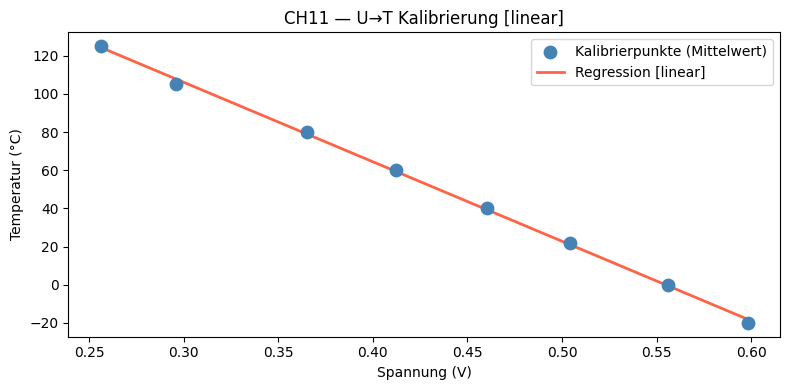

UtoT — 8 Temperaturpunkte nach Mittelung:
 temperature_c  voltage_v
         125.0   0.256160
         105.0   0.296133
          80.0   0.365417
          60.0   0.412333
          40.0   0.460333
          22.0   0.504000
           0.0   0.556033
         -20.0   0.598167
CH11 Regression [linear] — R² = 0.999179
Zeilen gelesen: 204 — Zeitspalten mit NaN: 0


,index,datetime,interval,CH1,CH2,CH3,CH4,CH5,CH6,CH7,CH8,CH9,CH10,CH11,Alarm1_10,Alarm11_20,AlarmOut
0,1,2026-02-03 08:48:45,0,22.50,22.75,22.75,22.80,22.70,22.50,22.60,22.35,22.70,224.745844,155.248031,LLLLLLLLLL,LLLLLLLLLL,LLLL
1,2,2026-02-03 08:48:45,250,22.50,22.60,22.90,22.70,22.70,22.50,22.45,22.60,22.70,232.859896,243.137586,LLLLLLLLLL,LLLLLLLLLL,LLLL
2,3,2026-02-03 08:48:45,500,22.45,22.65,22.65,22.70,22.65,22.45,22.55,22.30,22.65,224.745844,157.330722,LLLLLLLLLL,LLLLLLLLLL,LLLL
3,4,2026-02-03 08:48:45,750,22.45,22.50,22.80,22.65,22.65,22.50,22.35,22.55,22.60,232.859896,242.721048,LLLLLLLLLL,LLLLLLLLLL,LLLL
4,5,2026-02-03 08:48:46,0,22.45,22.65,22.60,22.70,22.65,22.45,22.55,22.35,22.70,224.745844,159.413413,LLLLLLLLLL,LLLLLLLLLL,LLLL


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   index       204 non-null    object        
 1   datetime    204 non-null    datetime64[ns]
 2   interval    204 non-null    object        
 3   CH1         204 non-null    float64       
 4   CH2         204 non-null    float64       
 5   CH3         204 non-null    float64       
 6   CH4         204 non-null    float64       
 7   CH5         204 non-null    float64       
 8   CH6         204 non-null    float64       
 9   CH7         204 non-null    float64       
 10  CH8         204 non-null    float64       
 11  CH9         204 non-null    float64       
 12  CH10        204 non-null    float64       
 13  CH11        204 non-null    float64       
 14  Alarm1_10   204 non-null    object        
 15  Alarm11_20  204 non-null    object        
 16  AlarmOut    204 non-null  

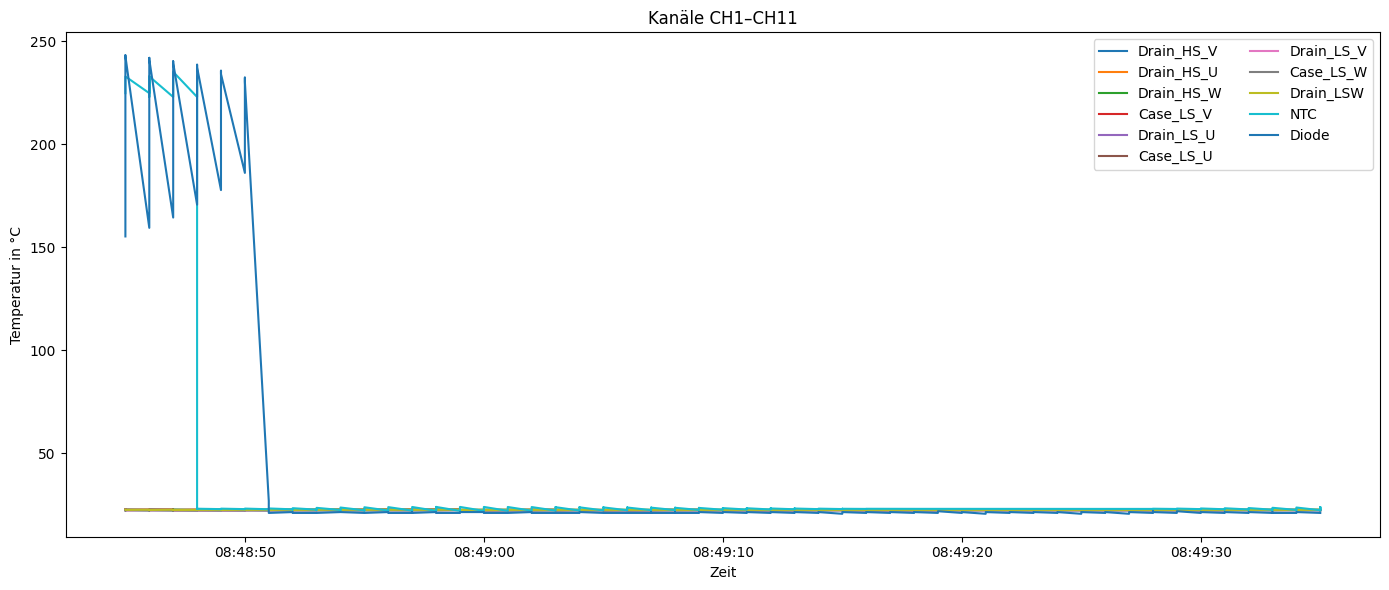

In [12]:
%matplotlib inline

# 1) Regression prüfen — CH11_REGRESSION oben ändern und neu ausführen
plot_ch11_regression(UTOT_PATH, method=CH11_REGRESSION)

# 2) Labels laden
labels = load_labels(LABELS_PATH)

# 3) Konverter bauen und CSV laden
ch11_conv   = build_ch11_converter(UTOT_PATH, method=CH11_REGRESSION)
df, ch_cols = read_and_clean(CSV_PATH, ch11_converter=ch11_conv, max_ch=MAX_CH)

print(f'Zeilen gelesen: {len(df)} — Zeitspalten mit NaN: {df["datetime"].isna().sum()}')
display(df.head())
df.info()

# 4) Plot
plot_channels(df, ch_cols, labels=labels)

# Optional: Plot speichern
# plot_channels(df, ch_cols, labels=labels, out_file='plot.png')